# 03 — Model Training

Day 4: train and evaluate baseline models (Ridge, Random Forest, XGBoost, LightGBM) with
spatially-aware cross-validation, tune the best one, and evaluate on a held-out spatial
test set. The pipeline logic lives in `src/models/train.py` (run via
`python -m src.models.train`) — this notebook calls those same functions directly so the
results shown here are guaranteed to match the saved `models/best_model.joblib`, and adds
visualizations to build intuition about *why* the numbers look the way they do. See
`DAY_4.md` for the full write-up.

This notebook runs entirely locally against the project's `.venv`. Select the **Python
(urbancool-melbourne)** kernel in VS Code.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (no pyproject.toml found in any parent)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: F:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

from src.data.loaders import load_config
from src.models.train import (
    FEATURE_COLS, GROUP_COL, TARGET_COL,
    build_models, evaluate_on_test, evaluate_with_cv, extract_feature_importance,
    load_model_data, spatial_train_test_split, tune_model,
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#2a78d6"
RED = "#e34948"
GREEN = "#008300"
GRAY = "#e1e0d9"
NEUTRAL = "#f0efec"
diverging_cmap = LinearSegmentedColormap.from_list("diverging", [BLUE, NEUTRAL, RED])

## 1. Load modeling data and look at the target

`load_model_data()` merges the Day 3 feature matrix with each SA2's SA3 region code (for
spatial grouping — see section 2) and drops the 8 SA2s with no heat target. That leaves
353 rows to model.

2026-07-09 00:27:07,280 INFO Loaded 361 SA2 rows, dropped 8 with no heat target -> 353 modeling rows


(353, 28)


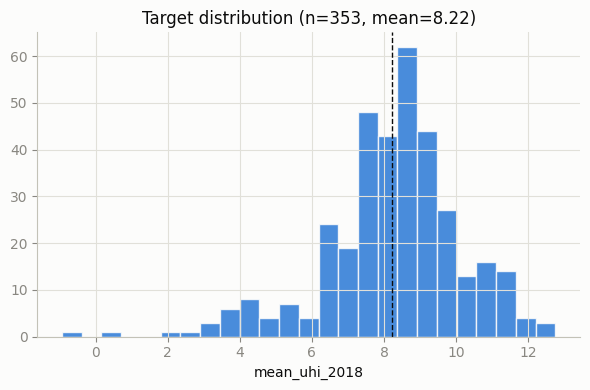

In [3]:
config = load_config()
data = load_model_data(config)
print(data.shape)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data[TARGET_COL], bins=25, color=BLUE, alpha=0.85, edgecolor="#fcfcfb")
ax.axvline(data[TARGET_COL].mean(), color="#0b0b0b", linewidth=1, linestyle="--")
ax.set_xlabel(TARGET_COL)
ax.set_title(f"Target distribution (n={len(data)}, mean={data[TARGET_COL].mean():.2f})")
fig.tight_layout()
plt.show()

## 2. Why a spatially-grouped split?

Random 80/20 splitting would scatter individual SA2s across train and test — including
splitting *adjacent* SA2s from the same neighbourhood, one into train and its next-door
neighbour into test. Because heat, vegetation, and built form are all spatially
autocorrelated (a suburb's climate and land use closely resemble its immediate
neighbours'), the model could partly "memorise" the local pattern from a training-set
neighbour rather than generalising — inflating the apparent test score. Grouping the
split by **SA3** (the ABS statistical region one level up from SA2 — Greater Melbourne
has ~40 of them, each containing a handful of adjacent SA2s) keeps whole neighbourhoods
on one side of the split, giving an honest read on how well the model generalises to
*unseen areas*, not just unseen rows.

train: 280 rows / 32 SA3 groups
test:  73 rows / 8 SA3 groups


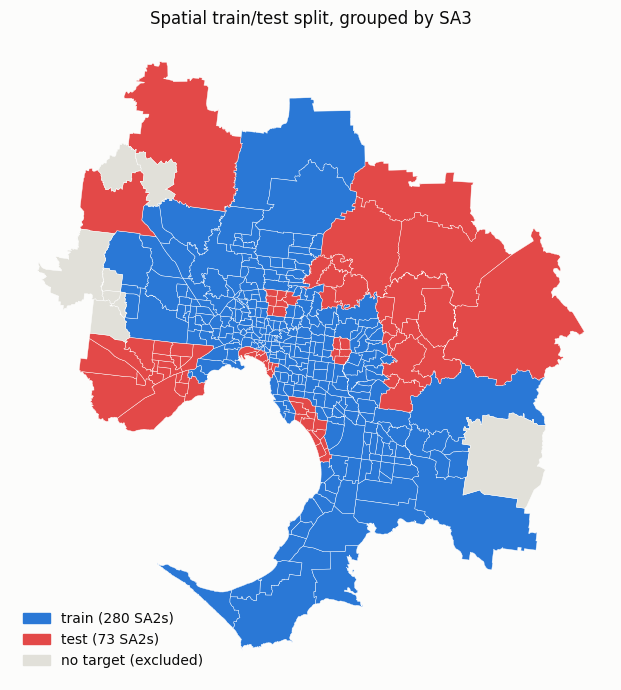

In [4]:
train, test = spatial_train_test_split(data, test_size=config["model"]["test_size"], random_state=config["model"]["random_state"])
print(f"train: {len(train)} rows / {train[GROUP_COL].nunique()} SA3 groups")
print(f"test:  {len(test)} rows / {test[GROUP_COL].nunique()} SA3 groups")

sa2 = gpd.read_parquet(PROJECT_ROOT / config["paths"]["data_interim"] / "sa2_boundaries.parquet")
split_gdf = sa2[["SA2_CODE21", "geometry"]].merge(
    pd.concat([train.assign(split="train"), test.assign(split="test")])[["SA2_CODE21", "split"]],
    on="SA2_CODE21", how="left",
)

fig, ax = plt.subplots(figsize=(7, 7))
split_gdf[split_gdf["split"] == "train"].plot(ax=ax, color=BLUE, edgecolor="white", linewidth=0.3)
split_gdf[split_gdf["split"] == "test"].plot(ax=ax, color=RED, edgecolor="white", linewidth=0.3)
split_gdf[split_gdf["split"].isna()].plot(ax=ax, color=GRAY, edgecolor="white", linewidth=0.3)
ax.legend(handles=[
    Patch(color=BLUE, label=f"train ({len(train)} SA2s)"),
    Patch(color=RED, label=f"test ({len(test)} SA2s)"),
    Patch(color=GRAY, label="no target (excluded)"),
], loc="lower left", frameon=False)
ax.set_title("Spatial train/test split, grouped by SA3")
ax.set_axis_off()
fig.tight_layout()
plt.show()

Note whole clusters of SA2s (entire SA3 regions) fall solidly into either the blue or
red group — no neighbourhood is split across both, which is the point.

## 3. Baseline model comparison

Five models, each wrapped in a `Pipeline` with its own median imputer (Ridge also gets a
`StandardScaler`) so cross-validation never leaks fold statistics. `Mean baseline` is a
`DummyRegressor` that always predicts the training-fold mean — it's the floor every real
model must beat, and it makes the R² values below directly interpretable ("how much
better than just guessing the average is this model?").

Evaluated with **grouped 5-fold cross-validation** (`GroupKFold` by SA3) on the training
set only — the test set stays untouched until section 5.

In [5]:
X_train, y_train, groups_train = train[FEATURE_COLS], train[TARGET_COL], train[GROUP_COL]
X_test, y_test = test[FEATURE_COLS], test[TARGET_COL]

models = build_models(config["model"]["random_state"])
cv_summary = evaluate_with_cv(models, X_train, y_train, groups_train)
cv_summary

,model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,Random Forest,1.163514,0.214878,0.886004,0.172384,0.454082,0.092299
1,LightGBM,1.164253,0.133085,0.874950,0.096282,0.428326,0.162354
2,XGBoost,1.215655,0.150470,0.909648,0.138008,0.388556,0.132096
3,Ridge,1.274378,0.245757,0.890861,0.114720,0.225523,0.566828
4,Mean baseline,1.766175,0.449367,1.346582,0.394519,-0.217344,0.192558


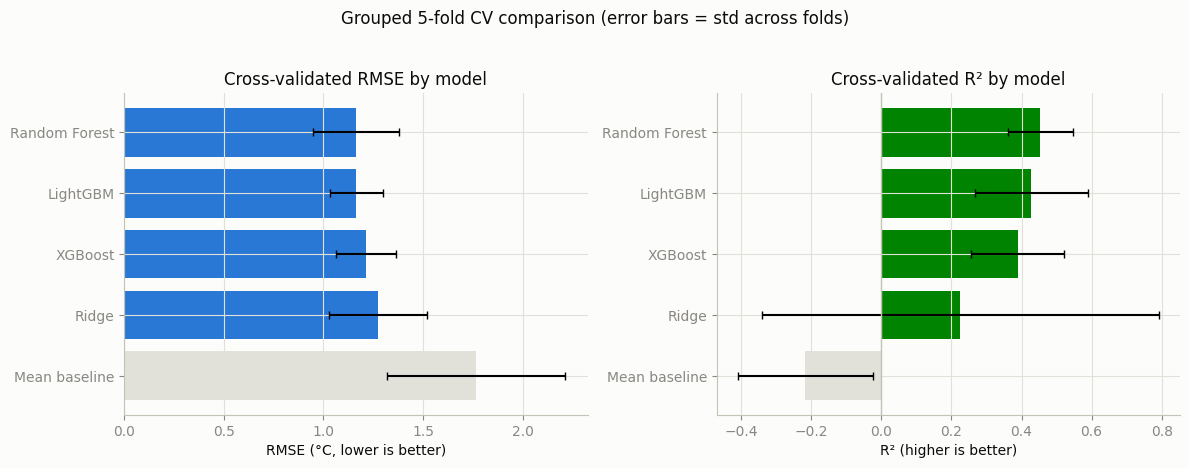

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = cv_summary["model"]
colors = [GRAY if m == "Mean baseline" else BLUE for m in order]
axes[0].barh(order, cv_summary["RMSE_mean"], xerr=cv_summary["RMSE_std"], color=colors, capsize=3)
axes[0].invert_yaxis()
axes[0].set_xlabel("RMSE (°C, lower is better)")
axes[0].set_title("Cross-validated RMSE by model")

colors2 = [GRAY if m == "Mean baseline" else GREEN for m in order]
axes[1].barh(order, cv_summary["R2_mean"], xerr=cv_summary["R2_std"], color=colors2, capsize=3)
axes[1].invert_yaxis()
axes[1].axvline(0, color="#c3c2b7", linewidth=1)
axes[1].set_xlabel("R² (higher is better)")
axes[1].set_title("Cross-validated R² by model")

fig.suptitle("Grouped 5-fold CV comparison (error bars = std across folds)", y=1.03)
fig.tight_layout()
plt.show()

**Reading the error bars**: the std-dev whiskers are wide relative to the gap between
models — with only 353 rows split into 5 spatial folds (~7-8 SA3 groups per fold), each
fold's score is noisy. The ranking between the top 3 models (Random Forest, LightGBM,
XGBoost) is not statistically decisive on this dataset; what *is* clear is that all three
comfortably beat both Ridge and the mean baseline, meaning the engineered features carry
real, non-linear signal about urban heat.

## 4. Hyperparameter tuning

`RandomizedSearchCV` over the winning model's hyperparameter space (30 random
combinations), still using the same grouped 5-fold CV so the search can't exploit
spatial leakage either.

In [7]:
best_name = cv_summary[cv_summary["model"] != "Mean baseline"].iloc[0]["model"]
print("Best baseline by CV RMSE:", best_name)

search = tune_model(best_name, X_train, y_train, groups_train, config["model"]["random_state"])
print("Tuned CV RMSE:", round(-search.best_score_, 4), "(baseline was", round(cv_summary.set_index("model").loc[best_name, "RMSE_mean"], 4), ")")
print("Best params:", search.best_params_)

Best baseline by CV RMSE: Random Forest


Tuned CV RMSE: 1.1587 (baseline was 1.1635 )
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 10}


## 5. Held-out test set evaluation

The 73 SA2s (8 whole SA3 regions) set aside in section 2 — never touched during CV or
tuning. This is the honest generalisation estimate.

In [8]:
test_metrics = evaluate_on_test(search.best_estimator_, X_test, y_test)
test_metrics

{'RMSE': 1.7012205729588088,
 'MAE': 1.0560987983077172,
 'R2': 0.46488971652763356}

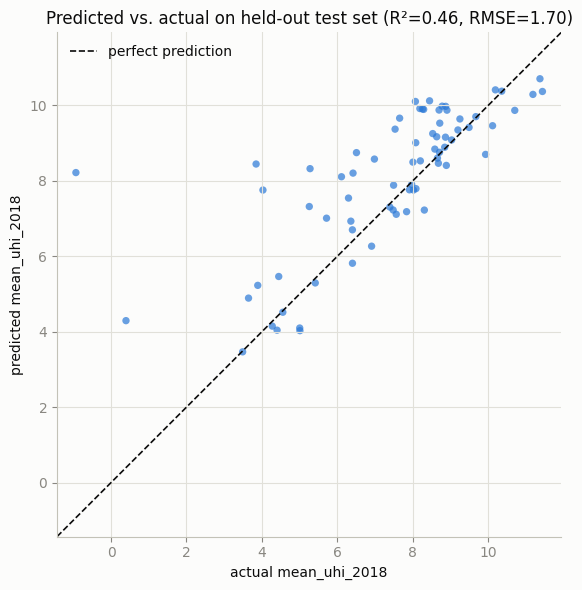

In [9]:
preds = search.best_estimator_.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds, s=28, color=BLUE, alpha=0.7, edgecolor="none")
lims = [min(y_test.min(), preds.min()) - 0.5, max(y_test.max(), preds.max()) + 0.5]
ax.plot(lims, lims, color="#0b0b0b", linewidth=1.2, linestyle="--", label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("actual mean_uhi_2018")
ax.set_ylabel("predicted mean_uhi_2018")
ax.set_title(f"Predicted vs. actual on held-out test set (R²={test_metrics['R2']:.2f}, RMSE={test_metrics['RMSE']:.2f})")
ax.legend(loc="upper left", frameon=False)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## 6. Where does the model get it wrong? A residual map

Residual = predicted − actual. Red areas are over-predicted (model says hotter than it
really is), blue areas are under-predicted — a diverging colormap centred on zero is the
right encoding here since the *sign* of the error matters, not just its size.

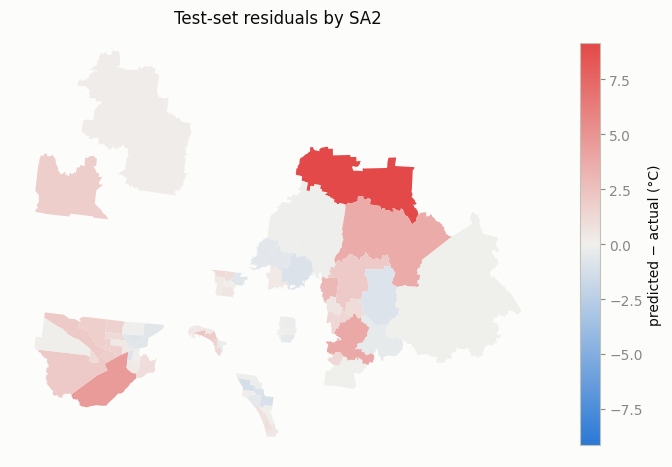

In [10]:
test_with_resid = test.copy()
test_with_resid["residual"] = preds - y_test.values

resid_gdf = sa2[["SA2_CODE21", "geometry"]].merge(test_with_resid[["SA2_CODE21", "residual"]], on="SA2_CODE21", how="right")

resid_max = test_with_resid["residual"].abs().max()
fig, ax = plt.subplots(figsize=(7, 7))
resid_gdf.plot(column="residual", cmap=diverging_cmap, vmin=-resid_max, vmax=resid_max, legend=True, ax=ax,
               legend_kwds={"label": "predicted − actual (°C)", "shrink": 0.6})
ax.set_title("Test-set residuals by SA2")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## 7. What is the model actually using?

Feature importance from the tuned model (tree-ensemble `feature_importances_` — impurity
reduction attributable to each feature, not a causal effect size).

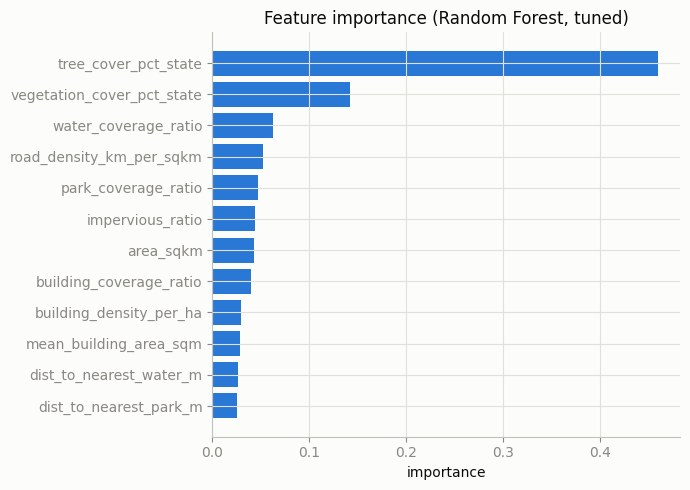

,feature,importance
0,tree_cover_pct_state,0.459291
1,vegetation_cover_pct_state,0.142367
2,water_coverage_ratio,0.062007
3,road_density_km_per_sqkm,0.052388
4,park_coverage_ratio,0.047467
5,impervious_ratio,0.043604
6,area_sqkm,0.042858
7,building_coverage_ratio,0.040017
8,building_density_per_ha,0.029897
9,mean_building_area_sqm,0.028757


In [11]:
importance = extract_feature_importance(search.best_estimator_, FEATURE_COLS)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importance["feature"], importance["importance"], color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.set_title(f"Feature importance ({best_name}, tuned)")
fig.tight_layout()
plt.show()

importance

## Takeaways

- **Spatial grouping matters for the split, not just the CV.** The single 80/20 test
  split happened to draw a more heterogeneous set of SA3 regions (including two rural
  fringe areas, Macedon Ranges and Yarra Ranges) than the average CV fold, so the
  held-out test RMSE is noticeably higher than the CV RMSE. That's a real property of
  evaluating on 8 held-out regions rather than a bug — see `DAY_4.md` for the full
  distributional comparison.
- **Tree ensembles clearly beat the linear baseline**, confirming the heat relationship
  is meaningfully non-linear (e.g. tree cover's cooling effect likely saturates rather
  than continuing linearly).
- **`tree_cover_pct_state` and `vegetation_cover_pct_state` dominate feature importance**,
  consistent with the correlation analysis in `02_feature_engineering.ipynb` — this is a
  useful cross-check that the model learned something matching the raw correlations,
  not something spurious.
- The saved `models/best_model.joblib` is refit on **all** 353 rows (train + test) using
  the tuned hyperparameters, since the held-out test estimate above has already been
  recorded — see `src/models/train.py::main()`.

See `DAY_4.md` for metric definitions, the concepts behind grouped CV, and full results.